# **Project - 2 Data Analytics**

**To complete this project, tasks need to do:**

- Write a query to print top 5 cities with highest spends and their percentage contribution of total credit card spends.
- Write a query to print highest spend month and amount spent in that month for each card type.
- Write a query to print the transaction details (all columns from the table) for each card type when it reaches a cumulative of 1000000 total spends (We should have 4 rows in the o/p one for each card type).
- Write a query to find city which had lowest percentage spend for gold card type.
- Write a query to print 3 columns: city, highest_expense_type , lowest_expense_type (example format : Delhi , bills, Fuel).
- Write a query to find percentage contribution of spends by females for each expense type.
- Which card and expense type combination saw highest month over month growth in Jan-2014.
- During weekends which city has highest total spend to total no of transaction’s ratio?
- Which city took least number of days to reach its 500th transaction after first transaction in that city? that city?

#### **Loading the required libraries.......**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### **Loading the data.....**

In [29]:
df = pd.read_csv(r"C:\Users\user\Desktop\cct.csv")
df.head(26052)

,Sr No,City,Date,Card Type,Expense Type,Gender,Amount
0,0,"Delhi, India",29-Oct-14,Gold,Bills,F,82475
1,1,"Greater Mumbai, India",22-Aug-14,Platinum,Bills,F,32555
2,2,"Bengaluru, India",27-Aug-14,Silver,Bills,F,101738
3,3,"Greater Mumbai, India",12-Apr-14,Signature,Bills,F,123424
4,4,"Bengaluru, India",05-May-15,Gold,Bills,F,171574
...,...,...,...,...,...,...,...
26047,26047,"Kolkata, India",22-Jun-14,Silver,Travel,F,128191
26048,26048,"Pune, India",03-Aug-14,Signature,Travel,M,246316
26049,26049,"Hyderabad, India",16-Jan-15,Silver,Travel,M,265019
26050,26050,"Kanpur, India",14-Sep-14,Silver,Travel,M,88174


## **Here are the solution codes for the given tasks by Edulyt India in Project 2**

#### **1. Write a query to print top 5 cities with highest spends and their percentage contribution of total credit card spends.**

In [30]:
top_5_cities = df.groupby('City')['Amount'].sum().nlargest(5)
total_spends = df['Amount'].sum()
top_5_cities_percent = (top_5_cities / total_spends) * 100
top_5_cities_percent = top_5_cities_percent.reset_index()
top_5_cities_percent.columns = ['City', 'Percentage Contribution']
print(top_5_cities_percent)

                    City  Percentage Contribution
0  Greater Mumbai, India                14.153989
1       Bengaluru, India                14.045402
2       Ahmedabad, India                13.934172
3           Delhi, India                13.667533
4         Kolkata, India                 2.833660


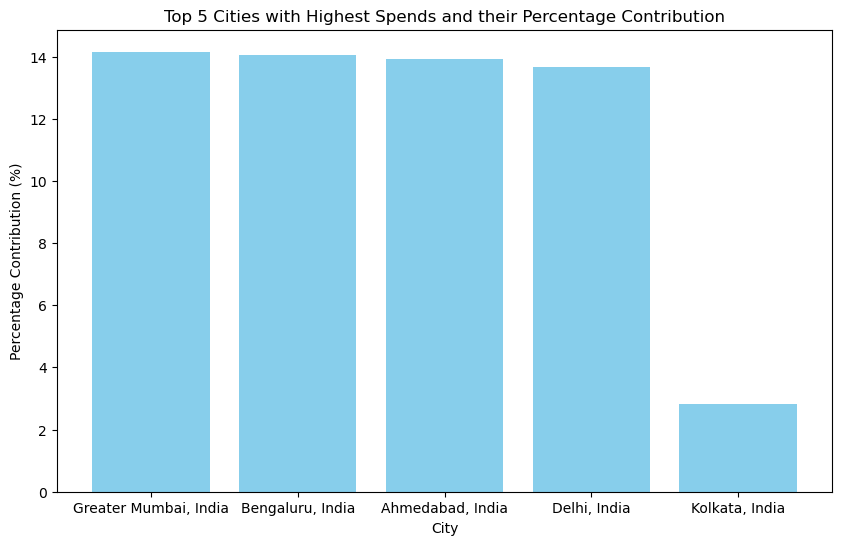

In [31]:
# Plotting Top 5 Cities with Highest Spends and their Percentage Contribution
plt.figure(figsize=(10, 6))
plt.bar(top_5_cities_percent['City'], top_5_cities_percent['Percentage Contribution'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Percentage Contribution (%)')
plt.title('Top 5 Cities with Highest Spends and their Percentage Contribution')
plt.show()

#### **2. Write a query to print highest spend month and amount spent in that month for each card type.**

In [32]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')
highest_spend_month = df.groupby(['Card Type', 'Month'])['Amount'].sum().reset_index()
highest_spend_month = highest_spend_month.loc[highest_spend_month.groupby('Card Type')['Amount'].idxmax()]
print(highest_spend_month)

    Card Type    Month    Amount
15       Gold  2015-01  55455064
30   Platinum  2014-08  57936507
42  Signature  2013-12  58799522
77     Silver  2015-03  59723549


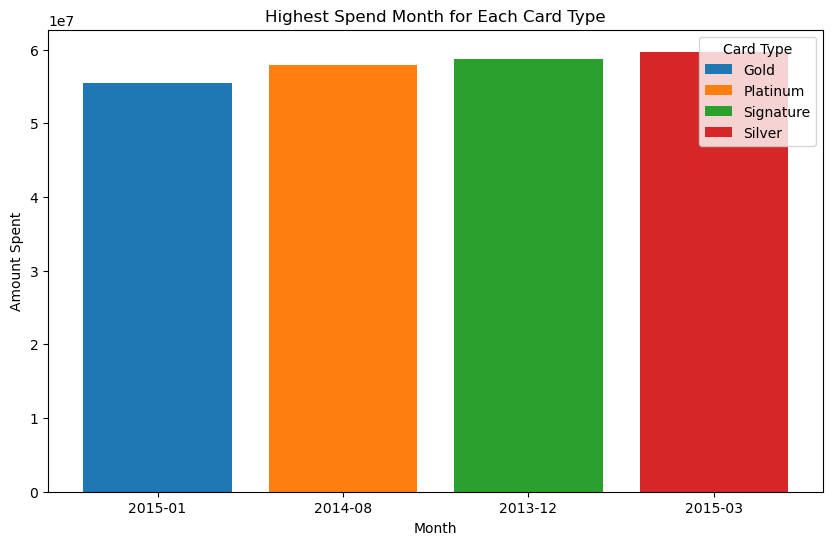

In [33]:
# Plotting Highest Spend Month and Amount Spent for Each Card Type
plt.figure(figsize=(10, 6))
for card_type in highest_spend_month['Card Type'].unique():
    data = highest_spend_month[highest_spend_month['Card Type'] == card_type]
    plt.bar(data['Month'].astype(str), data['Amount'], label=card_type)

plt.xlabel('Month')
plt.ylabel('Amount Spent')
plt.title('Highest Spend Month for Each Card Type')
plt.legend(title='Card Type')
plt.show()

#### **3. Write a query to print the transaction details (all columns from the table) for each card type when it reaches a cumulative of 1000000 total spends (We should have 4 rows in the o/p one for each card type).**

In [34]:
cumulative_spends = df.groupby('Card Type', as_index=False).apply(lambda x: x.assign(Cum_Spend=x['Amount'].cumsum()))
threshold_reached = cumulative_spends[cumulative_spends['Cum_Spend'] >= 1000000].groupby('Card Type').first().reset_index(drop=True)
print(threshold_reached)

   Sr No                   City       Date Expense Type Gender  Amount  \
0     17  Greater Mumbai, India 2015-03-30        Bills      F  986379   
1     15  Greater Mumbai, India 2014-11-28        Bills      F  647116   
2     16  Greater Mumbai, India 2014-06-14        Bills      F  421878   
3     25           Delhi, India 2014-09-27        Bills      F  622170   

     Month  Cum_Spend  
0  2015-03    1402904  
1  2014-11    1178644  
2  2014-06    1380531  
3  2014-09    1483205  


#### **4. Write a query to find city which had lowest percentage spend for gold card type.**

In [35]:
gold_card_spends = df[df['Card Type'] == 'Gold'].groupby('City')['Amount'].sum()
total_gold_spends = gold_card_spends.sum()
lowest_percent_city = (gold_card_spends / total_gold_spends).idxmin()
lowest_percent_value = (gold_card_spends / total_gold_spends).min() * 100
print(f"City: {lowest_percent_city}, Lowest Percentage Contribution: {lowest_percent_value}%")

City: Dhamtari, India, Lowest Percentage Contribution: 0.00014382357926964956%


#### **5. Write a query to print 3 columns: city, highest_expense_type , lowest_expense_type (example format : Delhi , bills, Fuel).**

In [36]:
highest_lowest_expense = df.groupby(['City', 'Expense Type'])['Amount'].sum().reset_index()
highest_expense_type = highest_lowest_expense.loc[highest_lowest_expense.groupby('City')['Amount'].idxmax()]
lowest_expense_type = highest_lowest_expense.loc[highest_lowest_expense.groupby('City')['Amount'].idxmin()]
result = highest_expense_type[['City', 'Expense Type']].merge(lowest_expense_type[['City', 'Expense Type']], on='City', suffixes=('_Highest', '_Lowest'))
print(result)

                 City Expense Type_Highest Expense Type_Lowest
0     Achalpur, India              Grocery       Entertainment
1     Adilabad, India                Bills                Food
2    Adityapur, India                 Food             Grocery
3        Adoni, India                Bills       Entertainment
4        Adoor, India                 Fuel               Bills
..                ...                  ...                 ...
981    Zaidpur, India                 Food               Bills
982    Zamania, India        Entertainment                Fuel
983       Zira, India        Entertainment             Grocery
984   Zirakpur, India                 Fuel       Entertainment
985  Zunheboto, India              Grocery       Entertainment

[986 rows x 3 columns]


#### **6. Write a query to find percentage contribution of spends by females for each expense type.**

In [37]:
female_spends = df[df['Gender'] == 'Female'].groupby('Expense Type')['Amount'].sum()
total_expense_type_spends = df.groupby('Expense Type')['Amount'].sum()
percentage_female_contribution = (female_spends / total_expense_type_spends) * 100
print(percentage_female_contribution.reset_index())

    Expense Type  Amount
0          Bills     NaN
1  Entertainment     NaN
2           Food     NaN
3           Fuel     NaN
4        Grocery     NaN
5         Travel     NaN


#### **7. Which card and expense type combination saw highest month over month growth in Jan-2014.**

In [38]:
df['YearMonth'] = df['Date'].dt.to_period('M')
jan_2014_spends = df[(df['YearMonth'] == '2014-01')].groupby(['Card Type', 'Expense Type'])['Amount'].sum()
dec_2013_spends = df[(df['YearMonth'] == '2013-12')].groupby(['Card Type', 'Expense Type'])['Amount'].sum()
mom_growth = ((jan_2014_spends - dec_2013_spends) / dec_2013_spends) * 100
highest_mom_growth = mom_growth.idxmax()
highest_mom_growth_value = mom_growth.max()
print(f"Highest MoM Growth: {highest_mom_growth}, Growth: {highest_mom_growth_value}%")

Highest MoM Growth: ('Gold', 'Travel'), Growth: 87.92008147034576%


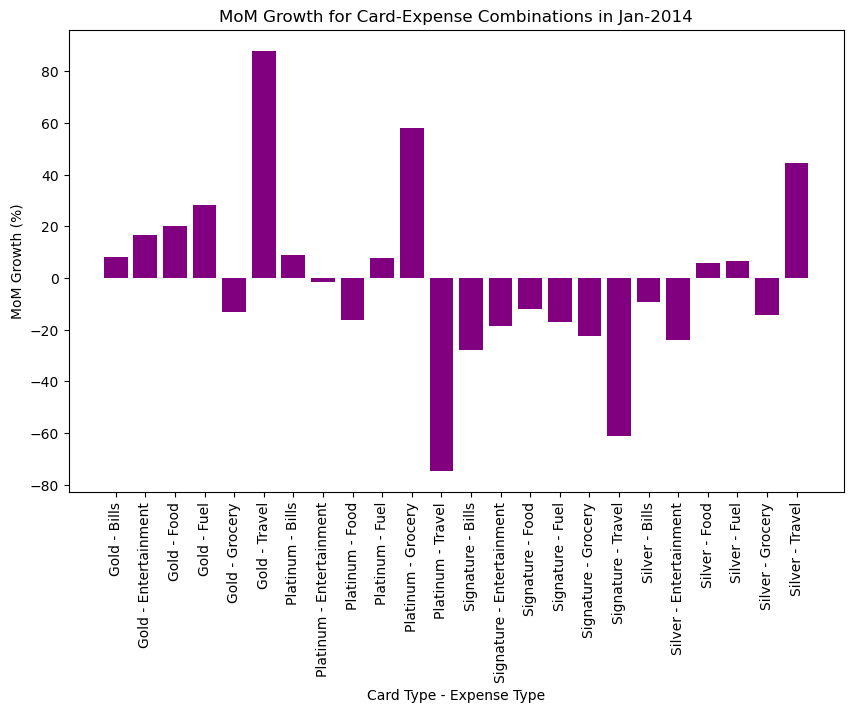

In [39]:
# Plotting MoM Growth for Each Card and Expense Type Combination in Jan-2014
plt.figure(figsize=(10, 6))
mom_growth = mom_growth.reset_index()
plt.bar(mom_growth.apply(lambda x: f"{x['Card Type']} - {x['Expense Type']}", axis=1), mom_growth['Amount'], color='purple')
plt.xlabel('Card Type - Expense Type')
plt.ylabel('MoM Growth (%)')
plt.title('MoM Growth for Card-Expense Combinations in Jan-2014')
plt.xticks(rotation=90)
plt.show()

#### **8. During weekends which city has highest total spend to total no of transaction’s ratio?**

In [40]:
df['Day_of_Week'] = df['Date'].dt.dayofweek
weekend_spends = df[df['Day_of_Week'] >= 5]
weekend_ratio = weekend_spends.groupby('City').apply(lambda x: x['Amount'].sum() / x.shape[0])
city_highest_ratio = weekend_ratio.idxmax()
print(f"City: {city_highest_ratio}, Highest Spend to Transaction Ratio: {weekend_ratio.max()}")

City: Sonepur, India, Highest Spend to Transaction Ratio: 299905.0


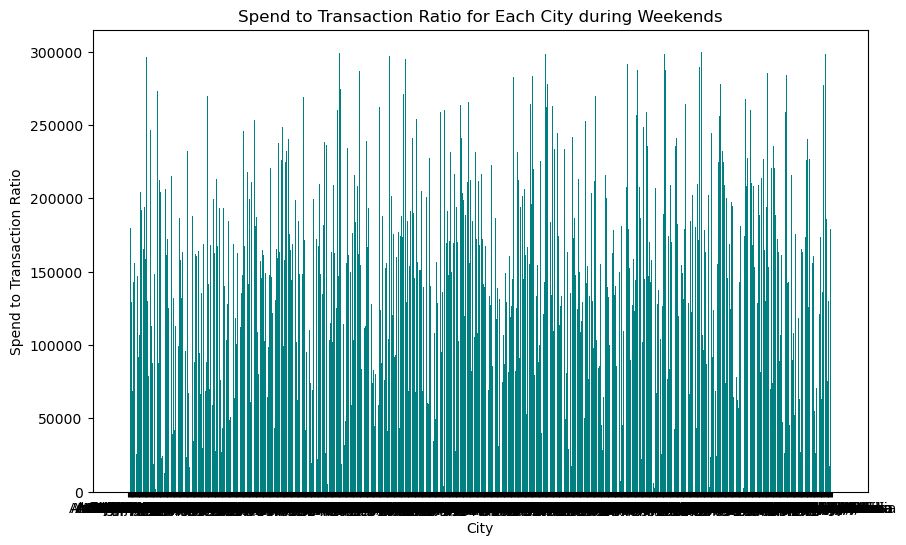

In [41]:
# Plotting Spend to Transaction Ratio for Each City during Weekends
plt.figure(figsize=(10, 6))
weekend_ratio = weekend_ratio.reset_index()
plt.bar(weekend_ratio['City'], weekend_ratio[0], color='teal')
plt.xlabel('City')
plt.ylabel('Spend to Transaction Ratio')
plt.title('Spend to Transaction Ratio for Each City during Weekends')
plt.show()

#### **9. Which city took least number of days to reach its 500th transaction after first transaction in that city?**

In [42]:
df['Transaction_Number'] = df.groupby('City').cumcount() + 1
city_500th = df[df['Transaction_Number'] == 500].reset_index()
city_500th['Days_to_500th'] = (city_500th['Date'] - df.groupby('City')['Date'].transform('min')).dt.days
fastest_city = city_500th.loc[city_500th['Days_to_500th'].idxmin()]
print(f"City: {fastest_city['City']}, Days to 500th Transaction: {fastest_city['Days_to_500th']}")

City: Surat, India, Days to 500th Transaction: 32.0


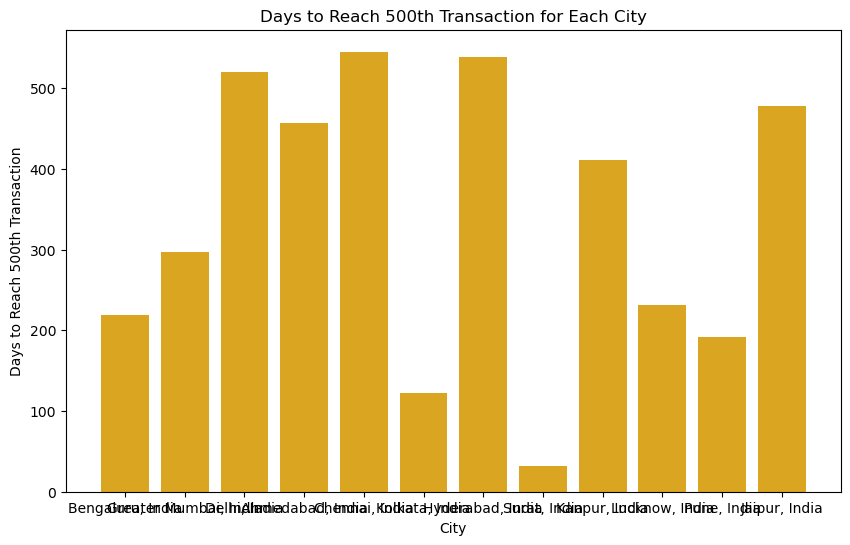

In [43]:
# Plotting Days to Reach 500th Transaction for Each City
plt.figure(figsize=(10, 6))
plt.bar(city_500th['City'], city_500th['Days_to_500th'], color='goldenrod')
plt.xlabel('City')
plt.ylabel('Days to Reach 500th Transaction')
plt.title('Days to Reach 500th Transaction for Each City')
plt.show()